<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Multivariate" data-toc-modified-id="Multivariate-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Multivariate</a></span></li><li><span><a href="#Univariate" data-toc-modified-id="Univariate-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Univariate</a></span></li></ul></div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import ccf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
wdf = pd.read_csv('waterlevel_54766010.csv')
rdf = pd.read_csv('rainfall_464636.csv')

print(wdf)
print(rdf)

                       Timestamp  Value
0      2023-01-01 00:00:00+00:00  0.910
1      2023-01-01 00:15:00+00:00  0.907
2      2023-01-01 00:30:00+00:00  0.903
3      2023-01-01 00:45:00+00:00  0.902
4      2023-01-01 01:00:00+00:00  0.899
...                          ...    ...
70171  2024-12-31 22:45:00+00:00  1.082
70172  2024-12-31 23:00:00+00:00  1.076
70173  2024-12-31 23:15:00+00:00  1.073
70174  2024-12-31 23:30:00+00:00  1.066
70175  2024-12-31 23:45:00+00:00  1.054

[70176 rows x 2 columns]
                       Timestamp  Value
0      2023-01-01 00:00:00+00:00    0.0
1      2023-01-01 00:15:00+00:00    0.0
2      2023-01-01 00:30:00+00:00    0.0
3      2023-01-01 00:45:00+00:00    0.0
4      2023-01-01 01:00:00+00:00    0.0
...                          ...    ...
70171  2024-12-31 22:45:00+00:00    0.0
70172  2024-12-31 23:00:00+00:00    0.0
70173  2024-12-31 23:15:00+00:00    0.8
70174  2024-12-31 23:30:00+00:00    0.6
70175  2024-12-31 23:45:00+00:00    0.6

[70176 rows x

In [3]:
wdf['Timestamp'] = pd.to_datetime(wdf['Timestamp']).dt.tz_localize(None)
rdf['Timestamp'] = pd.to_datetime(rdf['Timestamp']).dt.tz_localize(None)

print(wdf)
print(rdf)

                Timestamp  Value
0     2023-01-01 00:00:00  0.910
1     2023-01-01 00:15:00  0.907
2     2023-01-01 00:30:00  0.903
3     2023-01-01 00:45:00  0.902
4     2023-01-01 01:00:00  0.899
...                   ...    ...
70171 2024-12-31 22:45:00  1.082
70172 2024-12-31 23:00:00  1.076
70173 2024-12-31 23:15:00  1.073
70174 2024-12-31 23:30:00  1.066
70175 2024-12-31 23:45:00  1.054

[70176 rows x 2 columns]
                Timestamp  Value
0     2023-01-01 00:00:00    0.0
1     2023-01-01 00:15:00    0.0
2     2023-01-01 00:30:00    0.0
3     2023-01-01 00:45:00    0.0
4     2023-01-01 01:00:00    0.0
...                   ...    ...
70171 2024-12-31 22:45:00    0.0
70172 2024-12-31 23:00:00    0.0
70173 2024-12-31 23:15:00    0.8
70174 2024-12-31 23:30:00    0.6
70175 2024-12-31 23:45:00    0.6

[70176 rows x 2 columns]


In [4]:
# Data count
print(f"Initial Water Level data points: {len(wdf)}")
print(f"Initial Rainfall data points: {len(rdf)}")

Initial Water Level data points: 70176
Initial Rainfall data points: 70176


In [5]:
# Check for missing values
print("Water level missing values:\n", wdf.isnull().sum())
print("\nRainfall missing values:\n", rdf.isnull().sum())

Water level missing values:
 Timestamp    0
Value        0
dtype: int64

Rainfall missing values:
 Timestamp    0
Value        0
dtype: int64


In [6]:
# Check for duplicates
wdf = wdf.drop_duplicates(subset=['Timestamp']).dropna()
rdf = rdf.drop_duplicates(subset=['Timestamp']).dropna()

print(f"Water Level after cleaning: {len(wdf)}")
print(f"Rainfall after cleaning: {len(rdf)}")

Water Level after cleaning: 70176
Rainfall after cleaning: 70176


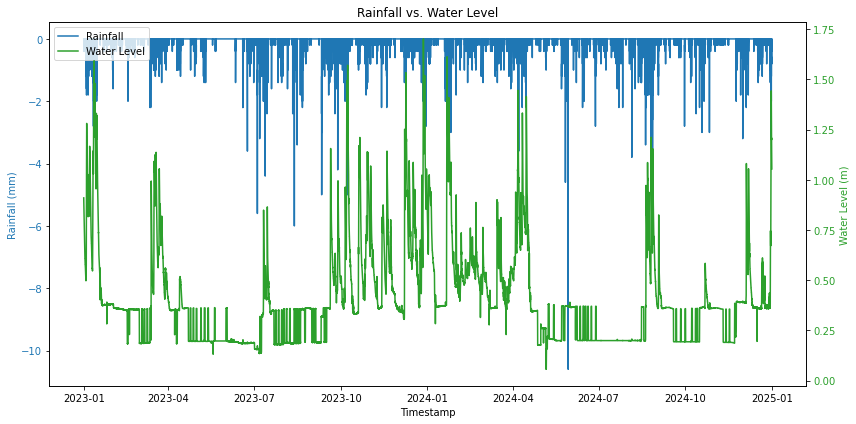

In [7]:
# Visualisation
plt.figure(figsize=(12, 6))

# Create primary axis
ax1 = plt.gca()
color = 'tab:blue'
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Rainfall (mm)', color=color)
ax1.plot(rdf['Timestamp'], -rdf['Value'], color=color, label='Rainfall')
ax1.tick_params(axis='y', labelcolor=color)

# Create secondary axis
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Water Level (m)', color=color)
ax2.plot(wdf['Timestamp'], wdf['Value'], color=color, label='Water Level')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
plt.title('Rainfall vs. Water Level')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [8]:
# Merge datasets
merged = pd.merge_asof(wdf.sort_values('Timestamp'), 
                      rdf.sort_values('Timestamp'), 
                      on='Timestamp',
                      direction='nearest',
                      tolerance=pd.Timedelta('15min'))
merged = merged.rename(columns={'Value_x': 'WaterLevel', 'Value_y': 'Rainfall'})
print(merged)

                Timestamp  WaterLevel  Rainfall
0     2023-01-01 00:00:00       0.910       0.0
1     2023-01-01 00:15:00       0.907       0.0
2     2023-01-01 00:30:00       0.903       0.0
3     2023-01-01 00:45:00       0.902       0.0
4     2023-01-01 01:00:00       0.899       0.0
...                   ...         ...       ...
70171 2024-12-31 22:45:00       1.082       0.0
70172 2024-12-31 23:00:00       1.076       0.0
70173 2024-12-31 23:15:00       1.073       0.8
70174 2024-12-31 23:30:00       1.066       0.6
70175 2024-12-31 23:45:00       1.054       0.6

[70176 rows x 3 columns]


In [9]:
# Correlation
corr, p_value = pearsonr(merged['WaterLevel'], merged['Rainfall'])
print(f"Pearson correlation: {corr:.3f} (p-value: {p_value:.3f})")

if abs(corr) < 0.3:
    print("Low correlation - suggesting time lag effects")

Pearson correlation: 0.163 (p-value: 0.000)
Low correlation - suggesting time lag effects


There is a weak positive correlation (0.163) between rainfall and water level at the exact same time point (lag=0) <br>
The p-value of 0.000 (typically meaning p < 0.001) suggests this correlation is statistically significant, meaning it's unlikely due to random chance.

In [10]:
x = merged['Rainfall'].values
y = merged['WaterLevel'].values

# Normalise
x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)

# Full cross-correlation
corrs = np.correlate(y, x, mode='full')
lags = np.arange(-len(x)+1, len(x))

# Find lag with maximum correlation
best_lag = lags[np.argmax(corrs)]
print(f"Max correlation at lag = {best_lag} samples")

# Convert lag to time
time_step = pd.to_timedelta('15min')
time_lag = best_lag * time_step
print(f"Time lag = {time_lag}")

Max correlation at lag = 38 samples
Time lag = 0 days 09:30:00


water level time series is most strongly correlated with rainfall that happened 38 time steps earlier <br>
38 samples × 15 minutes = 570 minutes = 9 hours 30 minutes <br>
Rainfall now will most strongly influence the water level ~9 hours 30 minutes later

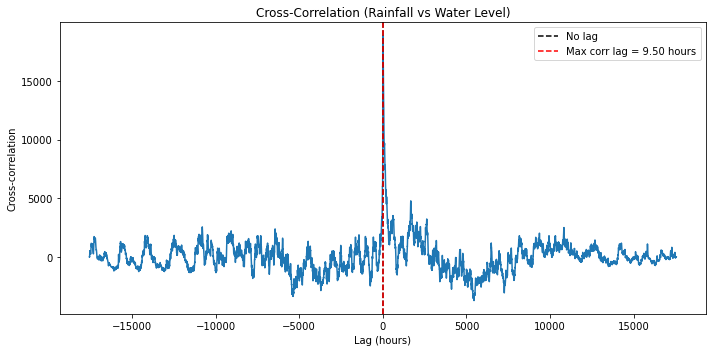

In [11]:
lags_hours = lags * (15/60)  # 15 minutes per sample
plt.figure(figsize=(10,5))
plt.plot(lags_hours, corrs)
plt.axvline(x=0, color='k', linestyle='--', label='No lag')
plt.axvline(x=best_lag*(15/60), color='r', linestyle='--', 
            label=f'Max corr lag = {best_lag*(15/60):.2f} hours')
plt.xlabel('Lag (hours)')
plt.ylabel('Cross-correlation')
plt.title('Cross-Correlation (Rainfall vs Water Level)')
plt.legend()
plt.tight_layout()
plt.show()

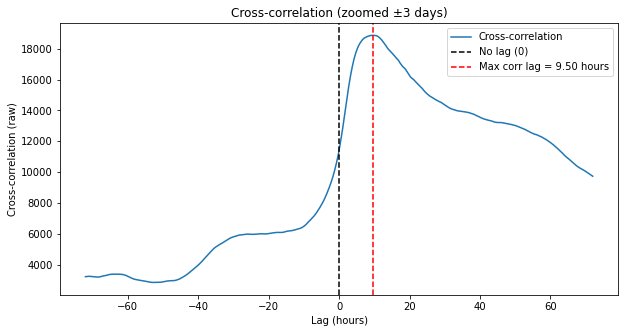

In [12]:
# Suppose you only care about ±3 days = 3*24 hours
max_hours = 3*24
mask = (lags_hours >= -max_hours) & (lags_hours <= max_hours)

plt.figure(figsize=(10,5))
plt.plot(lags_hours[mask], corrs[mask], label='Cross-correlation')
plt.axvline(x=0, color='k', linestyle='--', label='No lag (0)')
plt.axvline(x=best_lag*(15/60), color='r', linestyle='--', label=f'Max corr lag = {best_lag*(15/60):.2f} hours')
plt.xlabel('Lag (hours)')
plt.ylabel('Cross-correlation (raw)')
plt.title('Cross-correlation (zoomed ±3 days)')
plt.legend(loc='best')
plt.show()

In [13]:
# Split train / validation / test BEFORE scaling
train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

n = len(merged)
train_end = int(n * train_ratio)
val_end   = int(n * (train_ratio + val_ratio))

train_raw = merged[['Rainfall','WaterLevel']].iloc[:train_end]
val_raw   = merged[['Rainfall','WaterLevel']].iloc[train_end:val_end]
test_raw  = merged[['Rainfall','WaterLevel']].iloc[val_end:]

# Multivariate
Input(X): rainfall + water level <br>
Output(Y): water level

In [14]:
# Normalisation
scaler = MinMaxScaler()
scaler.fit(train_raw)

train_scaled = scaler.transform(train_raw)
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)

In [15]:
columns = ['Rainfall', 'WaterLevel']
train_df = pd.DataFrame(train_scaled, columns=columns)
validation_df = pd.DataFrame(val_scaled, columns=columns)
test_df = pd.DataFrame(test_scaled, columns=columns)

# Calculate statistical properties for each dataset
stats_train = train_df.describe().loc[['mean', 'std', 'min', 'max']]
stats_validation = validation_df.describe().loc[['mean', 'std', 'min', 'max']]
stats_test = test_df.describe().loc[['mean', 'std', 'min', 'max']]

# Compare the statistics
print("Training Data Stats:\n", stats_train, "\n")
print("Validation Data Stats:\n", stats_validation, "\n")
print("Testing Data Stats:\n", stats_test, "\n")

Training Data Stats:
       Rainfall  WaterLevel
mean  0.007953    0.239079
std   0.031539    0.160759
min   0.000000    0.000000
max   1.000000    1.000000 

Validation Data Stats:
       Rainfall  WaterLevel
mean  0.008493    0.151808
std   0.041253    0.107125
min   0.000000    0.084447
max   1.766667    0.702309 

Testing Data Stats:
       Rainfall  WaterLevel
mean  0.006871    0.172596
std   0.031558    0.093546
min   0.000000    0.078979
max   0.533333    0.842649 



In [16]:
# Create sequences for LSTM
def create_sequences(data, past_steps=40, forecast_horizon=1):
    X, y = [], []
    for i in range(len(data) - past_steps - forecast_horizon + 1):
        X.append(data[i : i + past_steps, :])                                      # past [Rainfall, WaterLevel]
        y.append(data[i + past_steps : i + past_steps + forecast_horizon, 1][-1])  # future WaterLevel
    return np.array(X), np.array(y)

past_steps = 40          # 40 × 15 min = 600 min = 10 hours
forecast_horizon = 1     # predict next step
X_train, y_train = create_sequences(train_scaled, past_steps, forecast_horizon)
X_val,   y_val   = create_sequences(val_scaled, past_steps, forecast_horizon)
X_test,  y_test  = create_sequences(test_scaled, past_steps, forecast_horizon)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (49083, 40, 2) (49083,)
Val:   (10486, 40, 2) (10486,)
Test:  (10487, 40, 2) (10487,)


In [17]:
# Build LSTM model
n_features = X_train.shape[2]

model = Sequential()
model.add(LSTM(64, input_shape=(past_steps, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',    # watch validation loss
    patience=10,           # stop if no improvement for 10 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
767/767 [==============================] - 43s 46ms/step - loss: 4.5070e-04 - val_loss: 6.2378e-05
Epoch 2/200
767/767 [==============================] - 38s 49ms/step - loss: 5.8140e-05 - val_loss: 3.9274e-05
Epoch 3/200
767/767 [==============================] - 44s 57ms/step - loss: 3.8849e-05 - val_loss: 2.9230e-05
Epoch 4/200
767/767 [==============================] - 41s 53ms/step - loss: 2.9275e-05 - val_loss: 1.9396e-05
Epoch 5/200
767/767 [==============================] - 42s 55ms/step - loss: 2.2554e-05 - val_loss: 1.4852e-05
Epoch 6/200
767/767 [==============================] - 45s 59ms/step - loss: 1.7135e-05 - val_loss: 1.1447e-05
Epoch 7/200
767/767 [==============================] - 48s 62ms/step - loss: 1.3749e-05 - val_loss: 9.7063e-06
Epoch 8/200
767/767 [==============================] - 45s 59ms/step - loss: 1.1569e-05 - val_loss: 8.1874e-06
Epoch 9/200
767/767 [==============================] - 54s 70ms/step - loss: 9.5235e-06 - val_loss: 6.4034e-06
E

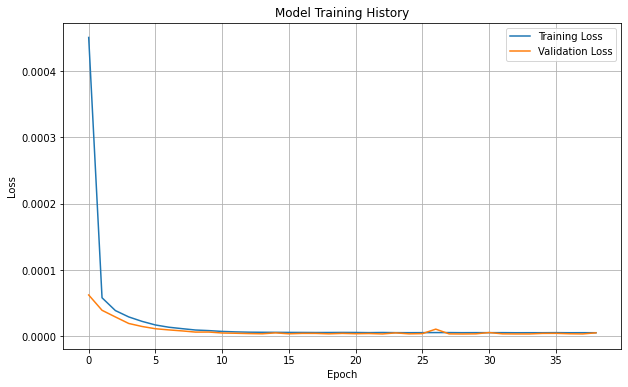

In [18]:
# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
y_pred_scaled = model.predict(X_test)

# Inverse-transform predictions
temp_pred = np.zeros((len(y_pred_scaled), 2))
temp_pred[:, 1] = y_pred_scaled[:, 0]
y_pred = scaler.inverse_transform(temp_pred)[:, 1]

temp_true = np.zeros((len(y_test), 2))
temp_true[:, 1] = y_test
y_true = scaler.inverse_transform(temp_true)[:, 1]

328/328 [==============================] - 8s 14ms/step


In [20]:
def plot_predictions_with_error(true_data, predicted_data, rainfall_data, title):
    plt.figure(figsize=(14, 6))
    
    true_data_flatten = true_data.flatten()
    predicted_data_flatten = predicted_data.flatten()
    rainfall_flatten = rainfall_data.flatten()
    
    error = true_data_flatten - predicted_data_flatten
    residuals_std = np.std(error)
    
    # --- Left subplot: water level + inverted rainfall ---
    ax1 = plt.subplot(1, 2, 1)
    
    # Plot true and predicted water level on primary y-axis
    line1, = ax1.plot(true_data_flatten, label='True Water Level', color='#1f77b4', linewidth=2)
    line2, = ax1.plot(predicted_data_flatten, label='Predicted Water Level', color='#ff7f0e', alpha=0.7, linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Water Level')
    ax1.set_title(title)
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # Create secondary y-axis for rainfall
    ax2 = ax1.twinx()
    line3, = ax2.plot(-rainfall_flatten, label='Inverted Rainfall', color='tab:blue', alpha=0.5)
    ax2.set_ylabel('Rainfall (inverted)')
    
    # Combine legends from ax1 and ax2 into one legend box on ax1
    lines = [line1, line2, line3]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(0, 0.9))
    
    # --- Second subplot: residuals ---
    ax3 = plt.subplot(1, 2, 2)
    ax3.scatter(predicted_data_flatten, error, alpha=0.5, label='Residuals')
    ax3.axhline(0, color='red', linestyle='--', label='Zero Error')
    ax3.set_xlabel('Predicted Water Level')
    ax3.set_ylabel('Residuals (True - Predicted)')
    ax3.set_title(f'Residual Plot (Std: {residuals_std:.3f})')
    ax3.legend(loc='upper right')
    ax3.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [21]:
train_pred = model.predict(X_train)
validation_pred = model.predict(X_val)
test_pred = model.predict(X_test)

328/328 [==============================] - 4s 13ms/step


In [22]:
rainfall_train = x[:len(y_train)]
rainfall_val = x[len(y_train):len(y_train) + len(y_val)]
rainfall_test = x[len(y_train) + len(y_val):len(y_train) + len(y_val) + len(y_test)]

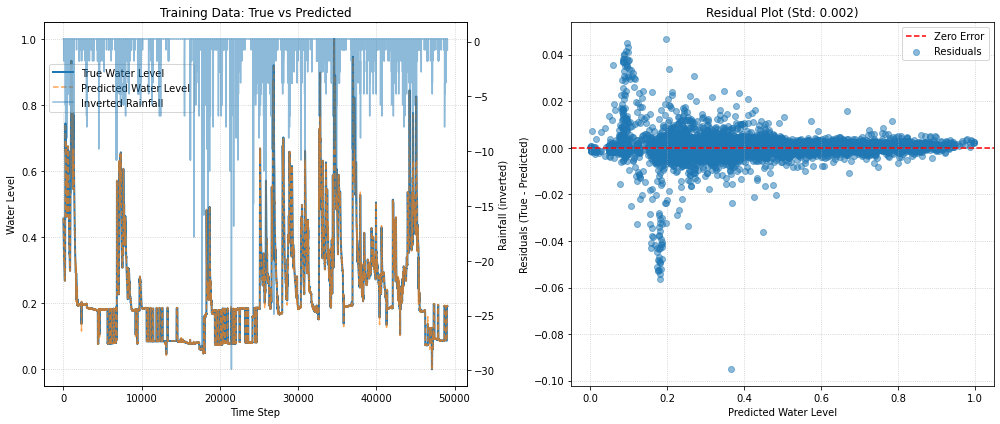

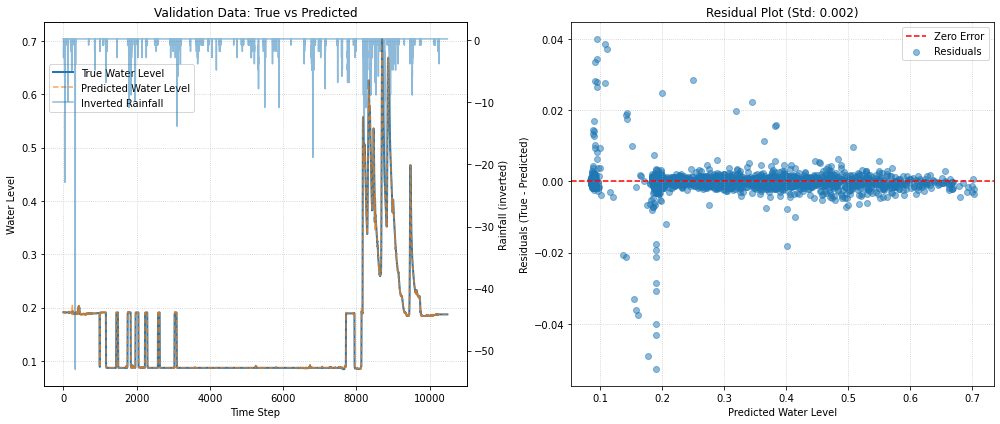

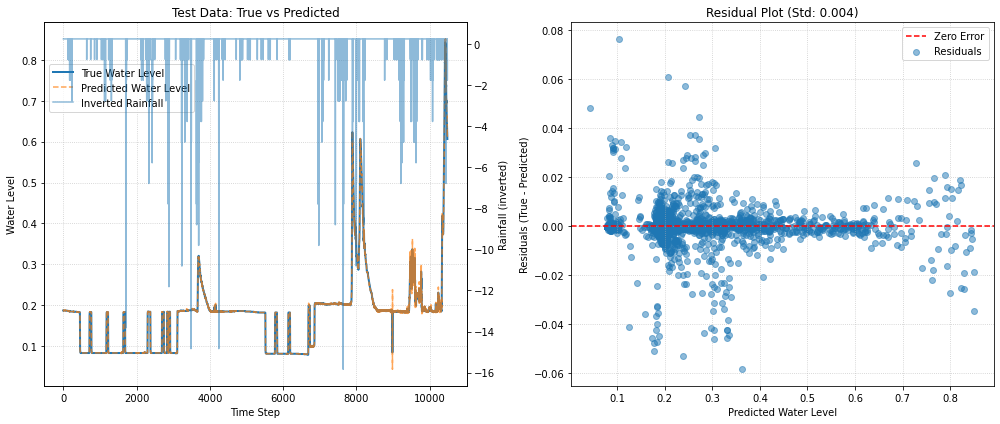

In [23]:
plot_predictions_with_error(y_train, train_pred, rainfall_train, 'Training Data: True vs Predicted')
plot_predictions_with_error(y_val, validation_pred, rainfall_val, 'Validation Data: True vs Predicted')
plot_predictions_with_error(y_test, test_pred, rainfall_test, 'Test Data: True vs Predicted')

In [24]:
# Compute fit stats
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

R²: 0.998
RMSE: 0.006
MAE: 0.002


# Univariate
Input(X): rainfall <br>
Output(Y): water level

In [25]:
scaler_rain = MinMaxScaler()
rain_scaled = scaler_rain.fit_transform(merged[['Rainfall']])  # only rainfall

# target (water level) in original scale or scaled separately
scaler_level = MinMaxScaler()
level_scaled = scaler_level.fit_transform(merged[['WaterLevel']])

# Combine into one array with rainfall as input and water level as output
# Handle separately in create_sequences
rain_scaled = rain_scaled.reshape(-1)    # flatten to 1D
level_scaled = level_scaled.reshape(-1)  # flatten to 1D

In [26]:
# Train/Validation/Test split
train_size = int(len(rain_scaled) * 0.7)
val_size   = int(len(rain_scaled) * 0.15)
test_size  = len(rain_scaled) - train_size - val_size

rain_train = rain_scaled[:train_size]
level_train = level_scaled[:train_size]

rain_val = rain_scaled[train_size:train_size+val_size]
level_val = level_scaled[train_size:train_size+val_size]

rain_test = rain_scaled[train_size+val_size:]
level_test = level_scaled[train_size+val_size:]

In [27]:
# Create sequences
def create_sequences_univariate(input_series, target_series, past_steps=40, forecast_horizon=1):
    X, y = [], []
    for i in range(len(input_series) - past_steps - forecast_horizon + 1):
        X.append(input_series[i : i + past_steps])  # past rainfall only
        y.append(target_series[i + past_steps : i + past_steps + forecast_horizon][-1])  # future water level
    return np.array(X), np.array(y)

past_steps = 40  # based on lag analysis (≈10 hours)
forecast_horizon = 1

X_train, y_train = create_sequences_univariate(rain_train, level_train, past_steps, forecast_horizon)
X_val, y_val = create_sequences_univariate(rain_val, level_val, past_steps, forecast_horizon)
X_test, y_test = create_sequences_univariate(rain_test, level_test, past_steps, forecast_horizon)

# Reshape X for LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (49083, 40, 1) (49083,)
Val: (10486, 40, 1) (10486,)
Test: (10487, 40, 1) (10487,)


In [28]:
model_uni = Sequential()
model_uni.add(LSTM(64, input_shape=(past_steps, 1)))  # 1 feature now
model_uni.add(Dense(1))
model_uni.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',    # watch validation loss
    patience=10,           # stop if no improvement for 10 epochs
    restore_best_weights=True
)

history_uni = model_uni.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
767/767 [==============================] - 59s 59ms/step - loss: 0.0219 - val_loss: 0.0162
Epoch 2/200
767/767 [==============================] - 44s 58ms/step - loss: 0.0201 - val_loss: 0.0184
Epoch 3/200
767/767 [==============================] - 43s 56ms/step - loss: 0.0199 - val_loss: 0.0153
Epoch 4/200
767/767 [==============================] - 42s 54ms/step - loss: 0.0199 - val_loss: 0.0152
Epoch 5/200
767/767 [==============================] - 41s 54ms/step - loss: 0.0198 - val_loss: 0.0170
Epoch 6/200
767/767 [==============================] - 40s 52ms/step - loss: 0.0198 - val_loss: 0.0196
Epoch 7/200
767/767 [==============================] - 40s 53ms/step - loss: 0.0198 - val_loss: 0.0165
Epoch 8/200
767/767 [==============================] - 45s 59ms/step - loss: 0.0197 - val_loss: 0.0190
Epoch 9/200
767/767 [==============================] - 42s 55ms/step - loss: 0.0197 - val_loss: 0.0191
Epoch 10/200
767/767 [==============================] - 42s 54ms/step - l

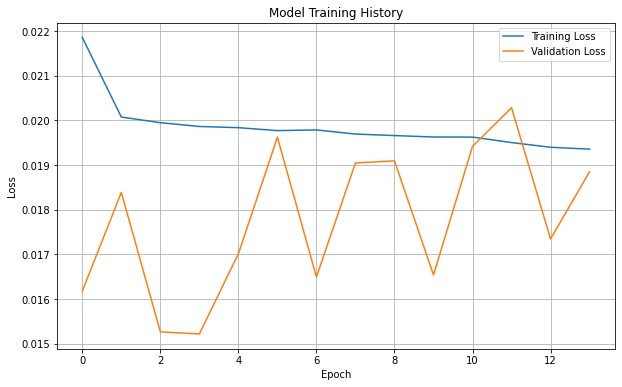

In [35]:
# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_uni.history['loss'], label='Training Loss')
plt.plot(history_uni.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
y_pred_scaled = model_uni.predict(X_test)

# inverse-transform predictions
y_pred = scaler_level.inverse_transform(y_pred_scaled)
y_true = scaler_level.inverse_transform(y_test.reshape(-1,1))

328/328 [==============================] - 7s 13ms/step


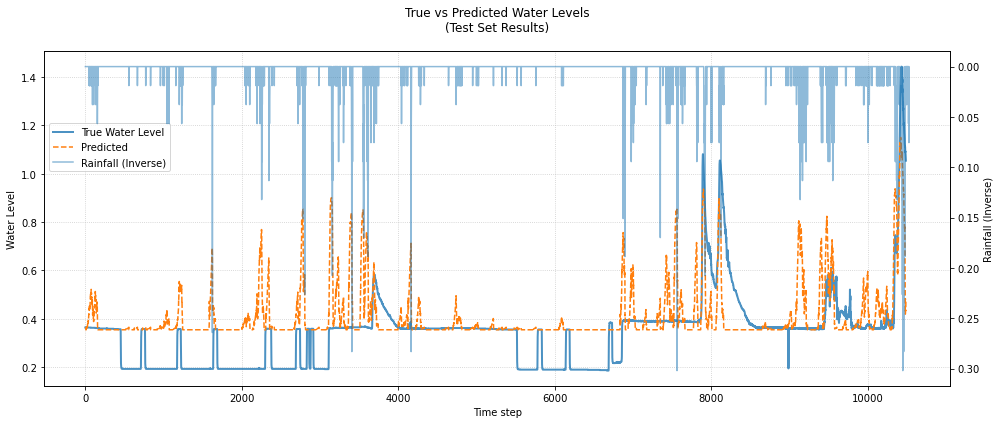

In [33]:
# Inverse-transform predictions and true values
y_pred = scaler_level.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_level.inverse_transform(y_test.reshape(-1, 1)).flatten()

rain_test_reshaped = rain_test.reshape(-1, 1)

# Plot settings
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(y_true, label='True Water Level', color='#1f77b4', linewidth=2, alpha=0.8)
ax1.plot(y_pred, label='Predicted', color='#ff7f0e', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Time step')
ax1.set_ylabel('Water Level')
ax1.grid(True, linestyle=':', alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(rain_test_reshaped, label='Rainfall (Inverse)', color='tab:blue', alpha=0.5)
ax2.set_ylabel('Rainfall (Inverse)')
ax2.invert_yaxis()  # invert y-axis for rainfall

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=10, loc='upper left', bbox_to_anchor=(0, 0.8))

plt.title('True vs Predicted Water Levels\n(Test Set Results)', pad=20)
plt.tight_layout()

In [31]:
# Compute fit stats
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

R²: 0.002
RMSE: 0.154
MAE: 0.110
